# 1. Gravitational waves, detection, and the TDR paper

This notebook builds the signal-analysis vocabulary needed for the Targeted Detectability Range (TDR), then traces the method and conclusions of Ronchini et al. (2026). The examples are synthetic and are not a search or an event analysis.

**By the end:** relate a compact-binary waveform to its detector response; explain PSD-weighted matched filtering and network SNR; distinguish an SNR threshold from detection significance; describe why searches use template banks; and state what the TDR does and does not claim.

## 1.1 From a binary to a strain signal

A compact binary inspiral loses orbital energy to gravitational radiation. Its orbital frequency rises, so the emitted GW “chirps” upward in frequency and amplitude before merger. A detector measures a dimensionless strain, approximately

$$d(t)=F_+(\alpha,\delta,\psi,t)h_+(t)+F_\times(\alpha,\delta,\psi,t)h_\times(t)+n(t),$$

where the antenna factors depend on sky position, polarization, and time, and $n(t)$ is detector noise. Distance reduces the signal amplitude approximately as $1/D_L$. Inclination changes the relative polarization amplitudes: a face-on binary is generally louder than an edge-on binary.

For a non-precessing, quasi-circular binary in the leading quadrupole approximation, a useful time-domain convention is

$$h_+(t)=A(t)\frac{1+\cos^2\iota}{2}\cos\Phi(t),\qquad h_\times(t)=A(t)\cos\iota\sin\Phi(t),$$

At Newtonian (leading quadrupole) order, the common amplitude scale can be written approximately as

$$A(t)=\frac{4}{D_L}\left(\frac{G\mathcal{M}}{c^2}\right)^{5/3}\left(\frac{\pi f_{\rm GW}(t)}{c}\right)^{2/3},$$

where $D_L$ is luminosity distance, $\mathcal{M}$ is chirp mass, and $f_{\rm GW}$ is the instantaneous GW frequency. The chirp mass therefore sets both the leading amplitude scale and (especially) how quickly the frequency and phase evolve. Spins alter the phase and, for precessing systems, the orientation and polarization over time; neutron-star tides affect late inspiral; eccentricity and higher waveform modes can change the simple quadrupole shape and inclination dependence. These effects are why production analyses use full waveform models rather than just this scaling. $\Phi(t)$ is the orbital/GW phase (up to convention), and $\iota$ is the angle between the orbital angular-momentum axis and the line of sight. Some waveform conventions reverse the sign of $h_\times$; this is a polarization-basis convention and does not change the physical prediction when used consistently. In the frequency domain the cross polarization is in quadrature (a factor of $i$) with the plus polarization, while their inclination factors remain $(1+\cos^2\iota)/2$ and $\cos\iota$.

At **face-on** ($\iota=0$), both angular factors are one: the signal is strongest and circularly polarized. At **edge-on** ($\iota=90^\circ$), the cross polarization vanishes and the plus factor is $1/2$: the signal is weaker and linearly polarized. Intermediate inclinations produce elliptical polarization. The common convention folds $\iota$ and $\pi-\iota$ into $0\leq\iota\leq\pi/2$; for a GRB jet, however, the line of sight is often expected to lie near one of the binary's two poles.

The measured strain is a second projection. $F_+$ and $F_\times$ are dimensionless antenna-pattern factors of a detector. They depend on the source direction (right ascension $\alpha$, declination $\delta$), the wave polarization angle $\psi$, the detector's orientation, and the Earth's rotation at observation time. Changing $\psi$ rotates the plus/cross basis by twice that angle, mixing $F_+$ and $F_\times$; it does not change the source's intrinsic radiation. The coalescence phase changes where the oscillation begins, while masses and spins set the chirp's phase evolution and intrinsic amplitude. Thus sky position and time change how a detector views a waveform, not the binary's emitted $h_+$ and $h_\times$.

## Effective distance

It is convenient to combine luminosity distance, antenna response, and inclination into the **effective distance** for one interferometer:

$$D_{\rm eff}=\frac{D_L}{\sqrt{F_+^2\left(\frac{1+\cos^2\iota}{2}\right)^2+F_\times^2\cos^2\iota}}. $$

The denominator is the source's relative amplitude response (in the quadrupole, orthogonal-polarization approximation). A face-on overhead source can have $D_{\rm eff}\simeq D_L$; an unfavorable sky location or edge-on orientation gives $D_{\rm eff}>D_L$, and at an antenna null it diverges. For a fixed waveform and PSD, SNR scales approximately as $1/D_{\rm eff}$. Effective distance is a useful way to compare projected amplitudes; it is **not** the source's actual luminosity distance and by itself does not calculate the SNR. A network generally has no single detector-independent effective distance: calculate each detector's response/SNR using its own PSD, then combine $\rho_{\rm net}=\sqrt{\sum_I\rho_I^2}$.

The next cell displays the antenna pattern for the user-selected GPS time and online interferometers. Edit `gps_time` and `online_ifos`, then rerun the cell. It shows $F_+$, $F_\times$ and the inclination-dependent amplitude response over sky direction. The map uses PyCBC’s `Detector.antenna_pattern` function. This optional cell requires PyCBC (`pip install pycbc`); the core notebooks do not otherwise depend on it.



In [17]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(20261008)
def chirp_mass(m1, m2):
    """Return chirp mass in the same units as m1 and m2."""
    return (m1 * m2) ** (3 / 5) / (m1 + m2) ** (1 / 5)

chirp_mass(1.4, 1.4)

1.2187707886145736

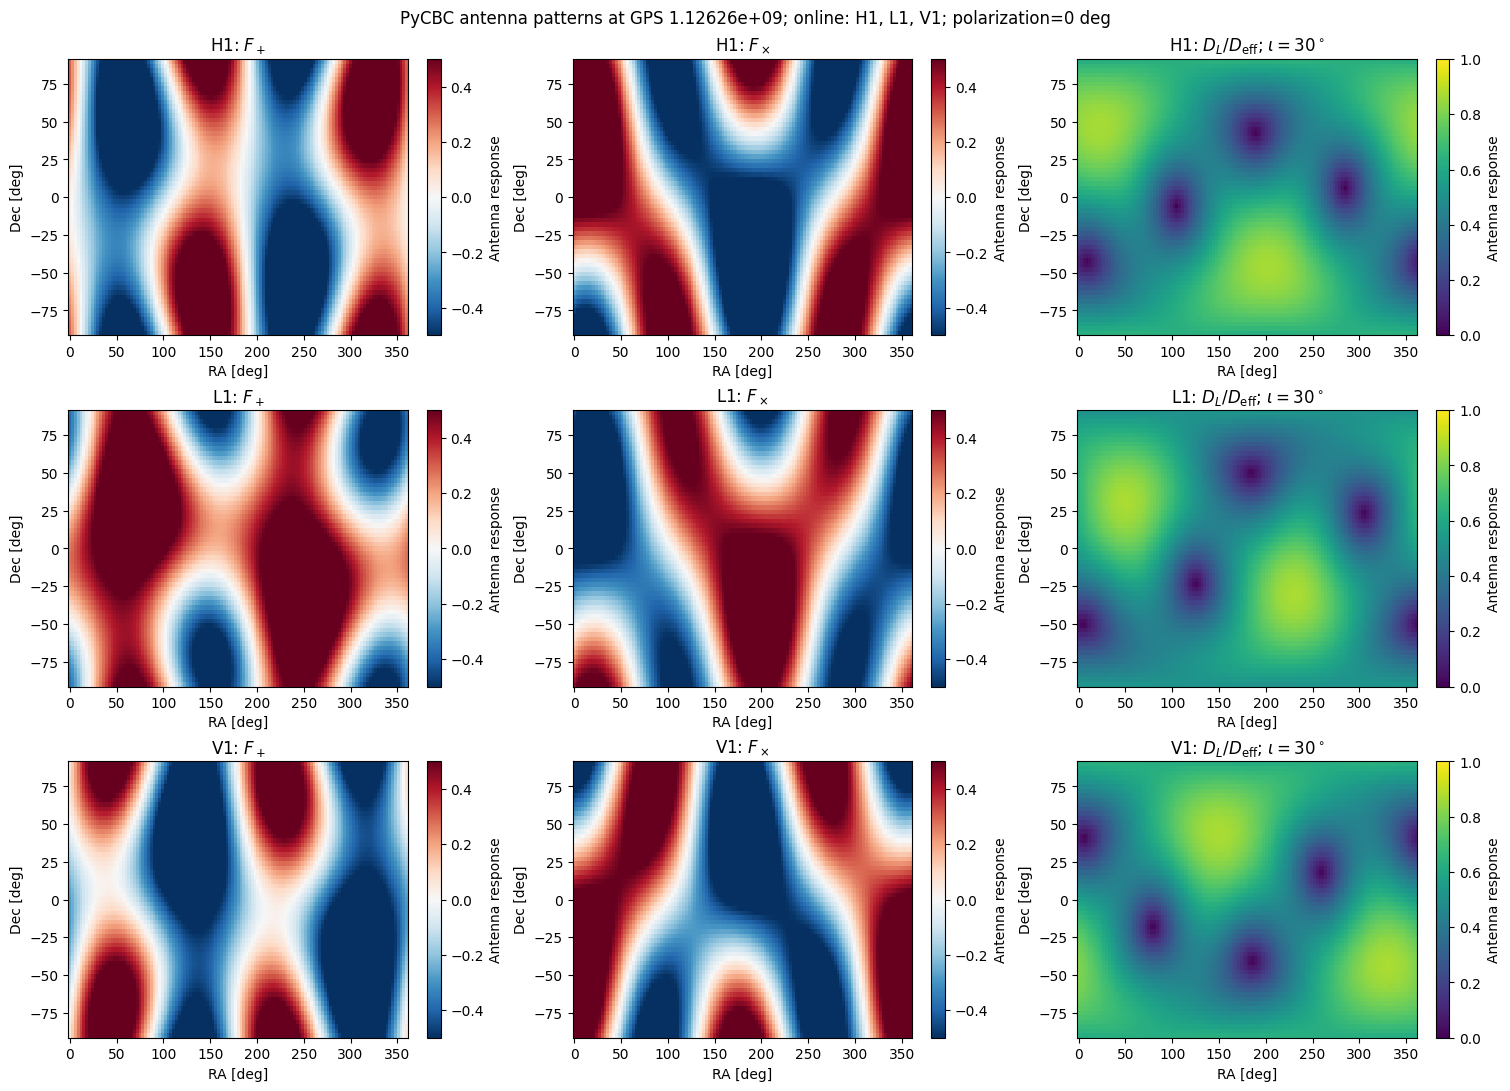

In [13]:
# User choices: GPS time and interferometers online at that event time.
from pycbc.detector import Detector

gps_time = 1126259462.4  # GPS seconds
online_ifos = ["H1", "L1", "V1"]  # Edit this list as needed.
inclination_deg = 30.0
polarization_deg = 0.0

if not online_ifos:
    raise ValueError("Select at least one online interferometer")
if not np.isfinite(gps_time) or gps_time < 0:
    raise ValueError("gps_time must be finite and non-negative")
if not 0 <= inclination_deg <= 90:
    raise ValueError("inclination_deg must be between 0 and 90 degrees")

# PyCBC expects RA, declination, and polarization in radians, and time in GPS seconds.
ra, dec = np.meshgrid(np.deg2rad(np.linspace(0, 360, 121)),
                      np.deg2rad(np.linspace(-90, 90, 61)))
psi = np.deg2rad(polarization_deg)
iota = np.deg2rad(inclination_deg)
cos_iota = np.cos(iota)
a_plus = (1 + cos_iota**2) / 2
fig, axes = plt.subplots(len(online_ifos), 3, figsize=(15, 3.6 * len(online_ifos)),
                         squeeze=False, constrained_layout=True)

for row, ifo in enumerate(online_ifos):
    detector = Detector(ifo)
    # PyCBC evaluates one sky position per call; vectorize it over the sky grid.
    antenna_pattern = np.vectorize(
        lambda ra_rad, dec_rad: detector.antenna_pattern(ra_rad, dec_rad, psi, gps_time),
        otypes=[float, float],
    )
    f_plus, f_cross = antenna_pattern(ra, dec)
    response = np.sqrt((f_plus * a_plus)**2 + (f_cross * cos_iota)**2)
    fields = [
        (f_plus, r"$F_+$", "RdBu_r", -0.5, 0.5),
        (f_cross, r"$F_\times$", "RdBu_r", -0.5, 0.5),
        (response, rf"$D_L/D_{{\rm eff}}$; $\iota={inclination_deg:g}^\circ$", "viridis", 0, 1),
    ]
    for col, (values, title, cmap, vmin, vmax) in enumerate(fields):
        image = axes[row, col].pcolormesh(np.rad2deg(ra), np.rad2deg(dec), values,
                                          shading="auto", cmap=cmap, vmin=vmin, vmax=vmax)
        axes[row, col].set(xlabel="RA [deg]", ylabel="Dec [deg]", title=f"{ifo}: {title}")
        fig.colorbar(image, ax=axes[row, col], label="Antenna response")

fig.suptitle(f"PyCBC antenna patterns at GPS {gps_time:g}; online: {', '.join(online_ifos)}; "
             f"polarization={polarization_deg:g} deg")
plt.show()


### A simple inspiral-shaped frequency-domain waveform

The leading inspiral amplitude in the frequency domain scales as $|\tilde h(f)|\propto\mathcal{M}^{5/6}f^{-7/6}/D_L$, where $\mathcal{M}=(m_1m_2)^{3/5}/(m_1+m_2)^{1/5}$ is the chirp mass. This scaling is useful for intuition, but merger, finite-size effects, spin, and the detector's frequency band matter in realistic waveforms.

The next cell plots the leading-order amplitude shape, normalized for display. It is deliberately not a calibrated waveform model and should not be used to quote a physical SNR.

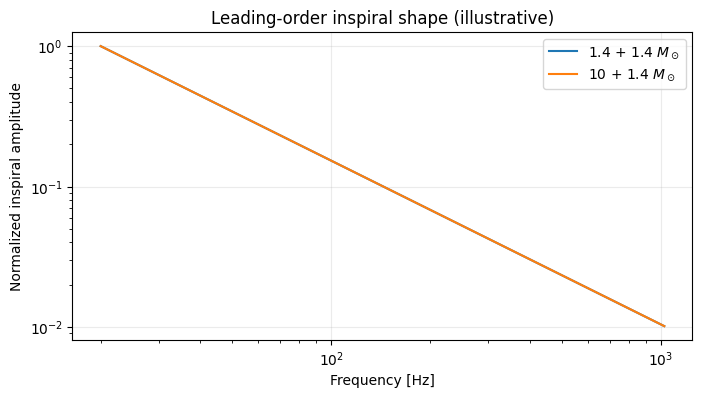

In [18]:
frequency = np.linspace(20, 1024, 2000)
mc_bns = chirp_mass(1.4, 1.4)
mc_heavier = chirp_mass(10.0, 1.4)

def inspiral_shape(f, mc):
    return mc ** (5 / 6) * f ** (-7 / 6)

plt.figure(figsize=(8, 4))
for mc, label in [(mc_bns, "1.4 + 1.4 $M_\\odot$"), (mc_heavier, "10 + 1.4 $M_\\odot$")]:
    amp = inspiral_shape(frequency, mc)
    plt.loglog(frequency, amp / amp.max(), label=label)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Normalized inspiral amplitude")
plt.title("Leading-order inspiral shape (illustrative)")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 1.2 Noise, PSD, and matched filtering

A one-sided noise power spectral density $S_n(f)$ describes how strain-noise power is distributed over frequency (units of strain$^2$/Hz). Frequency bins are not equally informative: a waveform component in a sensitive band contributes more than one buried in noisy frequencies.

For data $d$ and a template $h$, the noise-weighted inner product is

$$ (a|b)=4\,\mathrm{Re}\int_{f_L}^{f_H}\frac{\tilde a(f)\tilde b^*(f)}{S_n(f)}\,df. $$

Matched filtering correlates the data against templates while accounting for the PSD; maximizing over coalescence time and phase yields a detection statistic. The optimal SNR for a known signal is $\rho_{\rm opt}=\sqrt{(h|h)}$. In a network, independent detector SNRs combine in quadrature, $\rho_{\rm net}=\sqrt{\sum_I\rho_I^2}$.

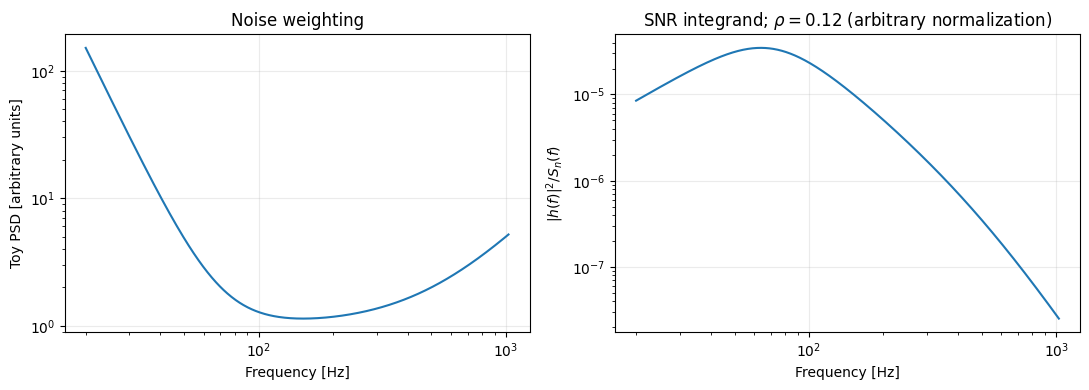

In [19]:
# A toy PSD: broad low-frequency noise plus a high-frequency rise.
psd = 1.0 + (70 / frequency) ** 4 + (frequency / 500) ** 2
h = inspiral_shape(frequency, mc_bns)
integrand = h**2 / psd
rho_squared = 4 * np.trapz(integrand, frequency)
rho = np.sqrt(rho_squared)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].loglog(frequency, psd)
axes[0].set(xlabel="Frequency [Hz]", ylabel="Toy PSD [arbitrary units]", title="Noise weighting")
axes[1].loglog(frequency, integrand)
axes[1].set(xlabel="Frequency [Hz]", ylabel="$|h(f)|^2/S_n(f)$", title=f"SNR integrand; $\\rho={rho:.2f}$ (arbitrary normalization)")
for ax in axes:
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 1.3 Template banks, matched filtering, and false-alarm rates

### Start with the template bank

A compact-binary search does not know the signal's component masses, spins, coalescence phase, or exact arrival time in advance. It builds a **template bank**: a discrete collection of modeled waveforms spanning the parameter space. The bank is designed so that the true signal is sufficiently similar to at least one template; the fractional loss in recovered signal-to-noise ratio from using the nearest template is called the mismatch. A denser bank usually reduces mismatch but increases computation and the number of noise opportunities to generate loud triggers.

Note: exaplain difference between a full PE and a low-latency search.

### Matched-filter computation

For a template $h$ and strain data $d$, first weight each Fourier-frequency bin by the detector noise PSD. With the one-sided PSD convention used above, define

$$ (a|b)=4\,\mathrm{Re}\int_{f_L}^{f_H}\frac{\tilde a(f)\tilde b^*(f)}{S_n(f)}\,df,\qquad \sigma_h^2=(h|h). $$

At one trial coalescence time and phase, the normalized matched-filter output is $\rho_h=(d|h)/\sigma_h$. In a real search, the filter is evaluated over many time shifts, and phase is usually maximized over using two orthogonal phase templates (equivalently the magnitude of a complex filter output). The search repeats this calculation across templates and detectors, then clusters nearby triggers so one signal/noise excursion is not counted many times. In ideal stationary Gaussian noise, a normalized filter output has a predictable noise distribution; real detector data also contain non-Gaussian glitches and non-stationarity.

The **optimal SNR** is different: it is the expected signal strength if the waveform and parameters are exactly known, $\rho_{\rm opt}=\sqrt{(h|h)}$. It has no random noise realization in it. A matched-filter SNR is an observed statistic in data, with noise fluctuations and possible template mismatch. For independent detectors, ideal optimal network SNRs combine as $\rho_{\rm opt,net}=\sqrt{\sum_I\rho_{{\rm opt},I}^2}$; searches use their actual network ranking statistic, which may also include consistency tests and data-quality information.

### From search background to FAR

A search estimates how often noise alone produces triggers at least as loud as a candidate. It constructs a **background** from data not containing the astrophysical on-source coincidence—for example, by shifting detector trigger times relative to each other so genuine coincident signals no longer line up, or by using off-source data. The complete search statistic is applied to that background, and the loudest background events are counted. If $N_{\rm bg}(\geq x)$ background events have ranking statistic at least $x$ in background live time $T_{\rm bg}$, then

$$\mathrm{FAR}(\geq x)=\frac{N_{\rm bg}(\geq x)}{T_{\rm bg}}. $$

Search pipelines account for their bank, event clustering, detector coincidences and ranking-statistic construction when building that background. The corresponding inverse false-alarm rate is $1/\mathrm{FAR}$. Under a Poisson background model, the probability of at least one background event this loud in an on-source duration $T_{\rm obs}$ is $1-\exp[-\mathrm{FAR}\,T_{\rm obs}]$; this is a false-alarm probability for that observation window, not the FAR itself.

SNR and significance are related but **not interchangeable**. A larger matched-filter SNR is generally more signal-like, but a raw SNR does not specify the FAR: loud glitches can have high SNR, and the background depends on the search, detector state, template bank, observing time, and ranking statistic. Searches often reweight SNR using signal-consistency tests (such as a chi-squared test) and then compare that ranking statistic with the empirical background. Therefore $\rho>9$ alone is neither a universal detection threshold nor a FAR/significance statement.

### The repository's optimal-to-matched-filter-like SNR conversion

The paper defines its detectability range using an SNR threshold. In the public `gw_tdr` implementation, the user can choose either optimal SNR (`opt`) or a stochastic *matched-filter-like* proxy (`mf`). The `mf` conversion implemented in [`aux_snr_mf.py`](https://github.com/samueleronchini/gw_tdr/blob/main/targ_ac_git/aux_snr_mf.py) is

$$k\sim\mathrm{Uniform}(0.9,1.0),\qquad X\sim\chi'^2_{\nu}\!\left(\Lambda\right),\qquad \nu=2N_{\rm IFO},\quad \Lambda=(k\rho_{\rm opt,net})^2,\qquad \rho_{\rm MF,like}=\sqrt{X}.$$

Here $N_{\rm IFO}$ is the number of included interferometers, $\nu$ is the chi-squared degrees of freedom, and $\Lambda$ is its noncentrality parameter. The noncentral chi-squared draw represents the squared magnitude of $N_{\rm IFO}$ complex matched-filter outputs: each detector contributes two phase quadratures, with the signal power set by the scaled optimal network SNR. The factor $k$ is independently sampled between 0.9 and 1.0 to allow a modest reduction from the ideal optimal SNR. The output is stochastic, and the noise quadratures mean $\rho_{\rm MF,like}$ is not simply $k\rho_{\rm opt,net}$.

**Important distinction:** this is the repository's approximate conversion for its `mf` option, not a substitute for filtering real detector data, applying a search's signal-consistency reweighting, or measuring its FAR. The `opt` option uses $\rho_{\rm opt,net}$ directly; the `mf` option uses the random proxy above. In either case, the TDR is conditional on the selected SNR cut and does not itself calculate a search FAR. Record the SNR convention and threshold with every result.

## 1.4 Paper schematic: targeted detectability range

[Ronchini et al. (2026)](https://arxiv.org/abs/2605.21578) condition GW detectability on information from an external messenger.

**Inputs** — trigger time; operating detectors and their noise PSDs; waveform/mass choices; source sky localization; inclination prior; SNR threshold.

**Calculation**

1. Estimate each detector PSD from 256 s of strain (Welch: 16 s segments, 50% overlap).
2. Generate reference SNR samples: TaylorF2 for BNS, IMRPhenomNSBH for NSBH; integrate over 30–1024 Hz.
3. Draw sky positions from the messenger sky map (or hold a precise position fixed) and draw isotropic inclinations, e.g. $0$–$45^\circ$ or $0$–$90^\circ$.
4. Rescale SNR by distance and antenna/effective-distance response; combine online-detector SNRs in quadrature.
5. Find the distance where the required fraction of draws remains above threshold:

$$P(\rho_{\rm net}>\rho_{\rm cut})=\lambda,\qquad \mathrm{TDR}=D_{90}\ (\lambda=0.9).$$

**Interpretation** — $D_{90}$ is the distance at which 90% of the assumed, prior-conditioned source draws exceed the chosen SNR cut. Since SNR scales as $1/D_L$, it is the 10th percentile of the draws' threshold horizons.

**Caveat** — This is a source-informed detectability estimate, not a search FAR or exclusion distance. The paper compares TDR with targeted-search 90% exclusion distances and finds a population-level correlation; the two quantities are not identical.

### Further reading

- [Ronchini et al. (2026), arXiv:2605.21578](https://arxiv.org/abs/2605.21578), published in *Astronomy & Astrophysics*.
- [GWOSC](https://gwosc.org/) for public strain data and detector information.
- [PyCBC documentation](https://pycbc.org/pycbc/latest/html/) for production waveform generation and SNR tools.
- [The `gw_tdr` repository](https://github.com/samueleronchini/gw_tdr) for the production implementation examined in the next notebook.